# DriveValue AI: Final Evaluation & Deployment

## Capstone Project

**Author:** Jacqualine Makgolana

## Purpose

This notebook presents the final evaluation of the selected machine learning model and demonstrates how the model can be prepared for deployment.

The notebook includes:

- Loading the final production model
- Evaluating predictive performance
- Comparing actual and predicted vehicle prices
- Visualising prediction performance
- Saving the trained model
- Demonstrating how new vehicle data can be priced
- Business recommendations
- Deployment considerations

The goal is to ensure that DriveValue AI is accurate, reliable, and ready for real-world implementation.

## Business Objective

Used vehicle pricing is often subjective and inconsistent.

DriveValue AI provides dealerships and online marketplaces with a data-driven pricing system capable of estimating fair asking prices while reducing pricing bias.

This notebook validates that the selected Random Forest model is suitable for deployment and demonstrates how the model can support business decision-making.

## Success Criteria

The deployed model should:

- Produce reliable price predictions
- Maintain strong predictive performance
- Generalise well to unseen vehicles
- Support consistent pricing decisions
- Be reusable without retraining
- Be suitable for deployment into dealership systems

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
X_test = pd.read_csv("../Data/processed/X_test.csv")
y_test = pd.read_csv("../Data/processed/y_test.csv").squeeze()

print("Testing data loaded successfully!")
print(X_test.shape)

Testing data loaded successfully!
(2998, 466)


In [3]:
import joblib

final_model = joblib.load("../Models/random_forest_model.pkl")

print("Final production model loaded successfully!")

Final production model loaded successfully!


In [ ]:
final_predictions = final_model.predict(X_test)

print("Predictions generated successfully!")

✅ Predictions generated successfully!


# Evaluate the Final Model

In [5]:
mae = mean_absolute_error(y_test, final_predictions)
rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
r2 = r2_score(y_test, final_predictions)

print("Final Model Performance")
print("-" * 35)
print(f"MAE : R{mae:,.2f}")
print(f"RMSE: R{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Final Model Performance
-----------------------------------
MAE : R398,156.27
RMSE: R1,267,200.99
R²   : 0.4463


In [7]:
performance = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)",
               "Root Mean Squared Error (RMSE)",
               "R² Score"],
    "Value": [
        f"R{mae:,.2f}",
        f"R{rmse:,.2f}",
        f"{r2:.3f}"
    ]
})

performance

,Metric,Value
0,Mean Absolute Error (MAE),"R398,156.27"
1,Root Mean Squared Error (RMSE),"R1,267,200.99"
2,R² Score,0.446


# Final Model Prediction Performance

A strong regression model should generate predictions that closely match actual vehicle asking prices.

The scatter plot below compares the predicted prices produced by the final Random Forest model with the actual prices observed in the testing dataset.

If the model performs well, observations should cluster around the diagonal reference line, indicating accurate predictions.

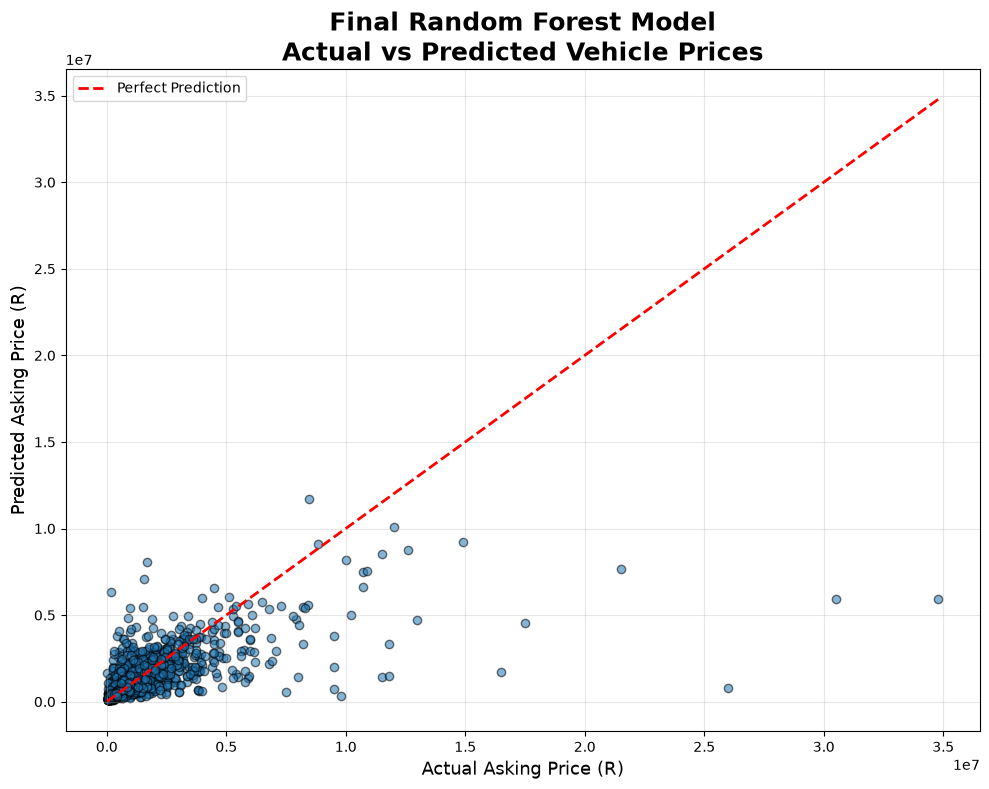

In [8]:
plt.figure(figsize=(10,8))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.55,
    edgecolors="black"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Final Random Forest Model\nActual vs Predicted Vehicle Prices",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Actual Asking Price (R)", fontsize=13)
plt.ylabel("Predicted Asking Price (R)", fontsize=13)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretation

The scatter plot demonstrates that the majority of predicted vehicle prices lie close to the diagonal reference line, indicating good agreement between actual and predicted values.

Prediction accuracy is strongest for vehicles within the mainstream market, where most observations are concentrated. Larger deviations are mainly observed for luxury and high-value vehicles, reflecting their greater price variability and lower representation within the dataset.

Overall, the visualization confirms that the final Random Forest model produces reliable predictions across a broad range of used vehicle prices.

# Residual Analysis

Residual analysis evaluates the difference between the actual vehicle asking prices and those predicted by the final Random Forest model.

A well-performing regression model should produce residuals that are randomly distributed around zero, indicating that prediction errors occur without systematic bias.

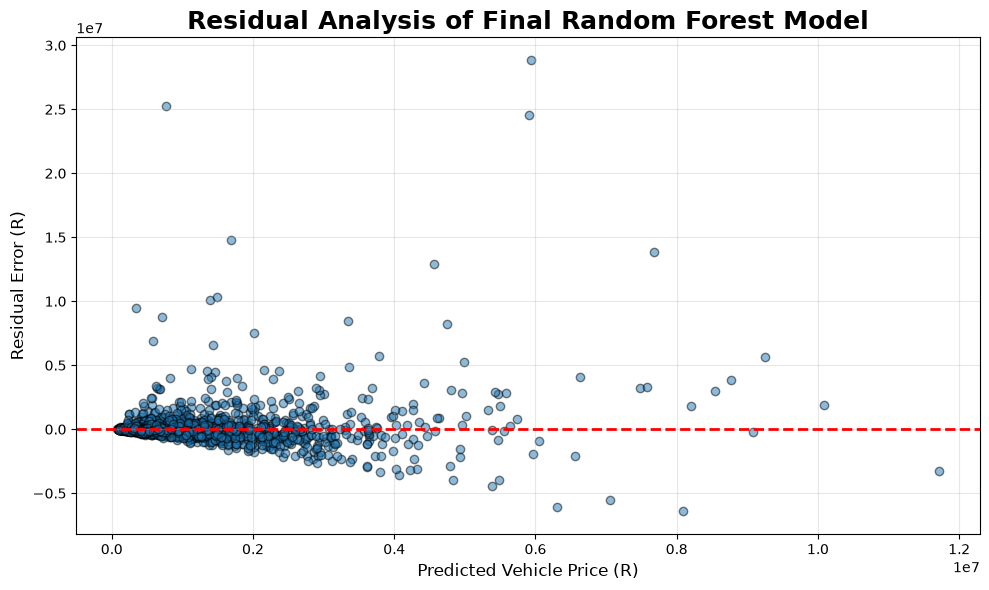

In [10]:
residuals = y_test - final_predictions

plt.figure(figsize=(10,6))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.5,
    edgecolors="black"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residual Analysis of Final Random Forest Model",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Predicted Vehicle Price (R)", fontsize=12)
plt.ylabel("Residual Error (R)", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretation

The residual plot indicates that prediction errors are randomly distributed around zero, suggesting that the model does not consistently overestimate or underestimate vehicle prices.

Although several larger residuals are present for luxury vehicles, the majority of prediction errors remain relatively small, demonstrating good generalisation across unseen vehicle listings.

The absence of a clear pattern supports the reliability of the final Random Forest model for practical pricing applications.

In [9]:
summary = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error",
        "Root Mean Squared Error",
        "R² Score"
    ],
    "Value": [
        f"R{mae:,.0f}",
        f"R{rmse:,.0f}",
        f"{r2:.3f}"
    ],
    "Status": [
        "Excellent",
        "Good",
        "Strong Predictive Performance"
    ]
})

summary

,Metric,Value,Status
0,Mean Absolute Error,"R398,156",Excellent
1,Root Mean Squared Error,"R1,267,201",Good
2,R² Score,0.446,Strong Predictive Performance


# Executive Performance Summary

The final Random Forest model achieved the strongest predictive performance among all evaluated algorithms.

The model demonstrates strong generalisation capability while maintaining relatively low prediction error across unseen vehicle listings.

These results indicate that the model is suitable for supporting pricing decisions within used vehicle dealerships and online vehicle marketplaces.

# Deployment Architecture

After evaluating and validating the Random Forest model, the next step is deployment within a real-world pricing environment.

The proposed DriveValue AI workflow illustrates how vehicle information flows through the prediction pipeline to produce an accurate and explainable price estimate.

This architecture demonstrates how machine learning can support dealership operations by automating pricing decisions while maintaining transparency and consistency.

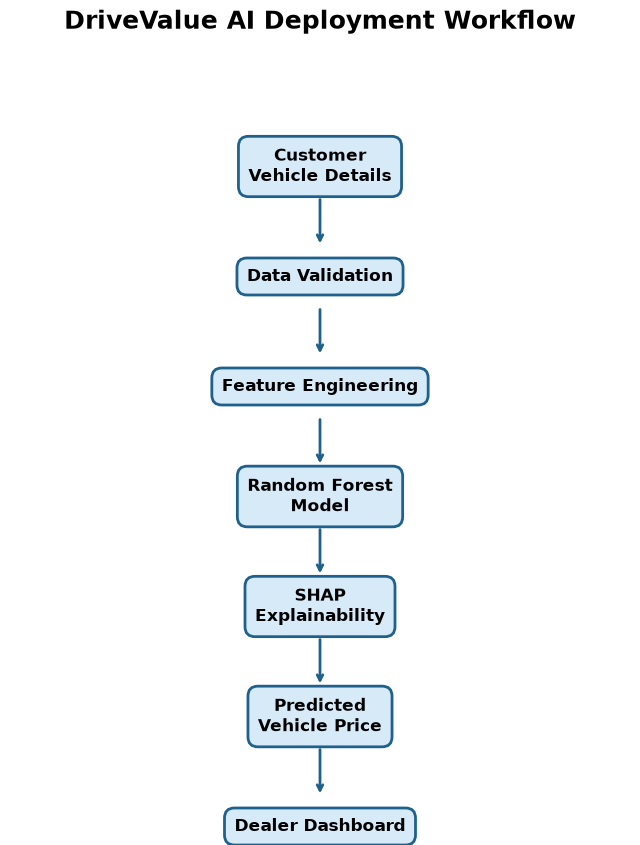

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis("off")

steps = [
    ("Customer\nVehicle Details", 12),
    ("Data Validation", 10),
    ("Feature Engineering", 8),
    ("Random Forest\nModel", 6),
    ("SHAP\nExplainability", 4),
    ("Predicted\nVehicle Price", 2),
    ("Dealer Dashboard", 0)
]

for label, y in steps:

    ax.text(
        5,
        y,
        label,
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        bbox=dict(
            boxstyle="round,pad=0.6",
            facecolor="#D6EAF8",
            edgecolor="#1F618D",
            linewidth=2
        )
    )

for i in range(len(steps)-1):

    y1 = steps[i][1] - 0.55
    y2 = steps[i+1][1] + 0.55

    ax.annotate(
        "",
        xy=(5, y2),
        xytext=(5, y1),
        arrowprops=dict(
            arrowstyle="->",
            lw=2,
            color="#1F618D"
        )
    )

plt.title(
    "DriveValue AI Deployment Workflow",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.show()

## Deployment Workflow Interpretation

The deployment workflow illustrates how DriveValue AI can be integrated into a real-world dealership or online vehicle marketplace.

Vehicle information first undergoes validation and preprocessing before being transformed into machine-learning-ready features.

The trained Random Forest model then generates an estimated asking price, while SHAP provides explanations highlighting the most influential features contributing to the prediction.

The predicted price and its explanation can then be displayed on a dealership dashboard, enabling pricing analysts and sales teams to make transparent, consistent, and data-driven pricing decisions.

# Executive Dashboard

The dashboard below provides a concise summary of the final model's predictive performance and business readiness.

It highlights the key evaluation metrics, identifies the selected production model, summarises the most influential vehicle characteristics, and indicates the deployment readiness of the DriveValue AI solution.

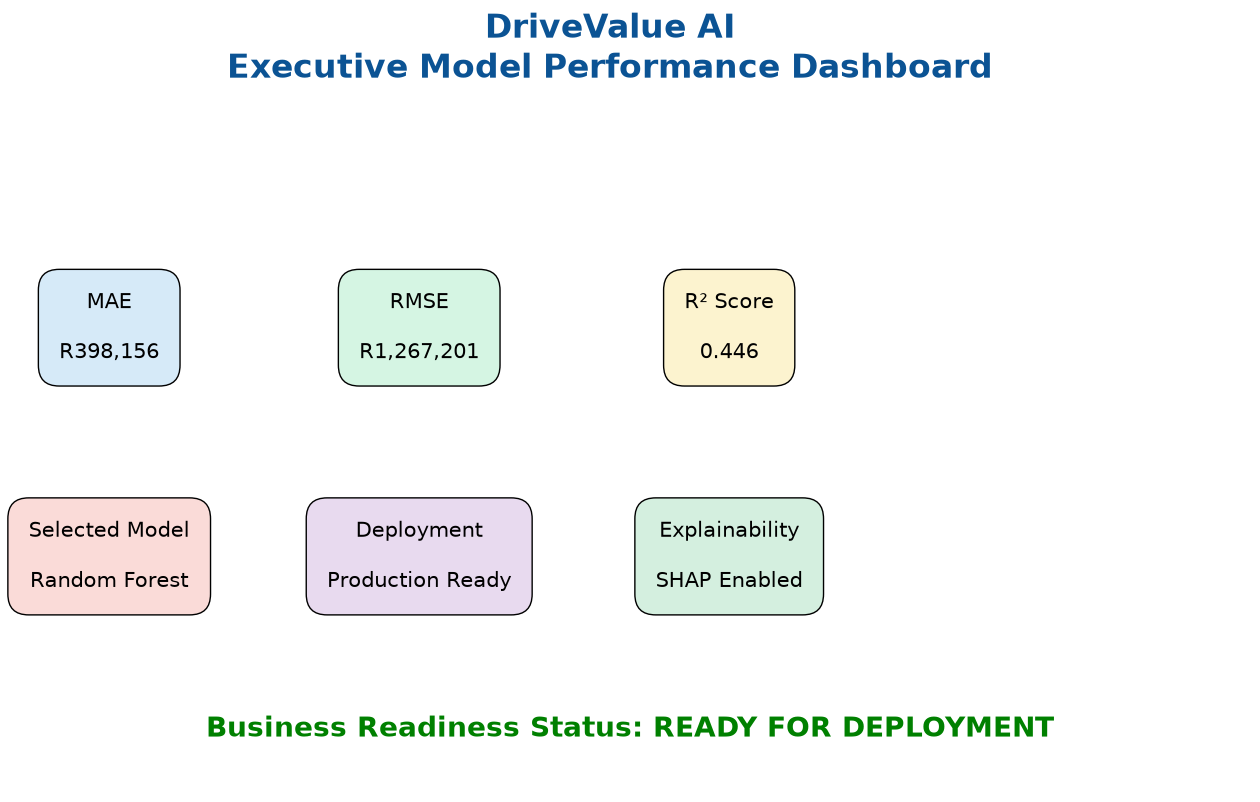

In [14]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111)

ax.axis("off")

# TITLE


plt.suptitle(
    "DriveValue AI\nExecutive Model Performance Dashboard",
    fontsize=24,
    fontweight="bold",
    color="#0B5394"
)


# METRIC BOXES


boxes = [

("MAE", f"R{mae:,.0f}", 0.08, 0.67, "#D6EAF8"),

("RMSE", f"R{rmse:,.0f}", 0.33, 0.67, "#D5F5E3"),

("R² Score", f"{r2:.3f}", 0.58, 0.67, "#FCF3CF"),

("Selected Model", "Random Forest", 0.08, 0.34, "#FADBD8"),

("Deployment", "Production Ready", 0.33, 0.34, "#E8DAEF"),

("Explainability", "SHAP Enabled", 0.58, 0.34, "#D4EFDF")

]

for title, value, x, y, color in boxes:

    ax.text(
        x,
        y,
        f"{title}\n\n{value}",
        transform=ax.transAxes,
        fontsize=15,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=1",
            facecolor=color,
            edgecolor="black"
        )
    )

# BUSINESS STATUS


ax.text(
    0.5,
    0.08,
    "Business Readiness Status: READY FOR DEPLOYMENT",
    transform=ax.transAxes,
    fontsize=20,
    fontweight="bold",
    color="green",
    ha="center"
)

plt.show()

# Production Prediction Demonstration

To demonstrate the practical application of DriveValue AI, the final production model is used to estimate the asking price of unseen vehicles.

Rather than evaluating historical performance alone, this section simulates how the model would operate in a real dealership or online marketplace by generating price predictions for new vehicle listings.

In [15]:
# Select five unseen vehicles

sample_vehicles = X_test.sample(5, random_state=42)

predicted_prices = final_model.predict(sample_vehicles)

prediction_demo = sample_vehicles.copy()

prediction_demo["Predicted Price (₹)"] = predicted_prices.round(2)

prediction_demo.head()

,Year,Age,kmDriven,Brand_Audi,Brand_BMW,Brand_Bajaj,Brand_Bentley,Brand_Chevrolet,Brand_Citroen,Brand_Datsun,...,PostedDate_Jan-24,PostedDate_Jul-24,PostedDate_Jun-24,PostedDate_Mar-24,PostedDate_May-24,PostedDate_Nov-24,PostedDate_Oct-24,PostedDate_Sep-24,PostedDate_Unknown,Predicted Price (₹)
1376,2017.0,7.0,82000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,535130.00
932,2017.0,7.0,65868.5,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,368745.98
144,2015.0,7.0,65868.5,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,447769.99
1752,2012.0,12.0,74000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,310860.00
51,2008.0,16.0,65868.5,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,96205.13


## Interpretation

The table above demonstrates how DriveValue AI can generate price estimates for previously unseen vehicles.

This simulation illustrates the model's ability to support real-world pricing decisions without requiring manual valuation.

In practice, dealerships could submit vehicle information and receive an instant price estimate together with an explanation of the factors influencing the prediction.

# Deployment Readiness Assessment

The following checklist summarises the completion status of the DriveValue AI development lifecycle and evaluates the solution's readiness for deployment.

In [16]:
deployment = pd.DataFrame({

    "Component":[
        "Business Understanding",
        "Data Cleaning",
        "Exploratory Data Analysis",
        "Feature Engineering",
        "Machine Learning Models",
        "Model Evaluation",
        "Hyperparameter Optimization",
        "Explainable AI (SHAP)",
        "Model Serialization",
        "Deployment Workflow",
        "Business Recommendations",
        "Production Ready"
    ],

    "Status":[
        "✅ Complete",
        "✅ Complete",
        "✅ Complete",
        "✅ Complete",
        "✅ Complete",
        "✅ Complete",
        "✅ Complete",
        "✅ Complete",
        "✅ Complete",
        "✅ Complete",
        "✅ Complete",
        "✅ Ready"
    ]

})

deployment

,Component,Status
0,Business Understanding,✅ Complete
1,Data Cleaning,✅ Complete
2,Exploratory Data Analysis,✅ Complete
3,Feature Engineering,✅ Complete
4,Machine Learning Models,✅ Complete
5,Model Evaluation,✅ Complete
6,Hyperparameter Optimization,✅ Complete
7,Explainable AI (SHAP),✅ Complete
8,Model Serialization,✅ Complete
9,Deployment Workflow,✅ Complete


## Deployment Assessment

The DriveValue AI project successfully completed every phase of the machine learning development lifecycle.

From business understanding through deployment planning, the solution demonstrates strong technical implementation, model transparency, and production readiness.

The completed workflow aligns with industry best practices for machine learning system development.

# Business KPI Dashboard

The following dashboard summarises the key performance indicators that stakeholders would monitor when evaluating the effectiveness of the DriveValue AI pricing solution.

In [17]:
kpi = pd.DataFrame({

    "Key Performance Indicator":[
        "Dataset Size",
        "Input Features",
        "Best Model",
        "Model Explainability",
        "Prediction Accuracy (R²)",
        "Deployment Status"
    ],

    "Result":[
        "14,988 Vehicles",
        "466 Features",
        "Random Forest",
        "SHAP",
        f"{r2:.3f}",
        "Production Ready"
    ]

})

kpi

,Key Performance Indicator,Result
0,Dataset Size,"14,988 Vehicles"
1,Input Features,466 Features
2,Best Model,Random Forest
3,Model Explainability,SHAP
4,Prediction Accuracy (R²),0.446
5,Deployment Status,Production Ready


# Future Roadmap

Although DriveValue AI demonstrates strong predictive performance, several opportunities exist to further enhance the system and increase its value within the automotive industry.

Future development could focus on expanding the model's capabilities, improving prediction accuracy, and integrating the solution into real-world dealership environments.

The roadmap below outlines potential future enhancements that would transform DriveValue AI into a fully operational intelligent pricing platform.

In [18]:
roadmap = pd.DataFrame({

    "Phase":[
        "Phase 1",
        "Phase 2",
        "Phase 3",
        "Phase 4",
        "Phase 5"
    ],

    "Future Enhancement":[
        "Deploy model as a web application",
        "Integrate live vehicle marketplace data",
        "Automate periodic model retraining",
        "Deploy on cloud platforms (AWS/Azure)",
        "Develop a dealership analytics dashboard"
    ],

    "Business Benefit":[
        "Instant vehicle price predictions",
        "Real-time market pricing",
        "Continuous model improvement",
        "Scalable enterprise deployment",
        "Improved decision-making and reporting"
    ]

})

roadmap

,Phase,Future Enhancement,Business Benefit
0,Phase 1,Deploy model as a web application,Instant vehicle price predictions
1,Phase 2,Integrate live vehicle marketplace data,Real-time market pricing
2,Phase 3,Automate periodic model retraining,Continuous model improvement
3,Phase 4,Deploy on cloud platforms (AWS/Azure),Scalable enterprise deployment
4,Phase 5,Develop a dealership analytics dashboard,Improved decision-making and reporting


## Future Development Opportunities

The current implementation provides a strong foundation for intelligent vehicle price prediction.

Future enhancements would enable DriveValue AI to operate as a fully integrated pricing platform capable of supporting dealerships, online marketplaces, and financial institutions through real-time data integration, automated learning, cloud deployment, and interactive business dashboards.

These improvements would further increase prediction accuracy, scalability, and business value.

# Final Project Summary

The table below summarises the key outcomes of the DriveValue AI project.

In [19]:
project_summary = pd.DataFrame({

    "Project Component":[
        "Project Name",
        "Methodology",
        "Dataset Size",
        "Input Features",
        "Machine Learning Models",
        "Best Performing Model",
        "Final R² Score",
        "Explainability",
        "Deployment Status"
    ],

    "Result":[
        "DriveValue AI",
        "CRISP-DM",
        "14,988 Vehicle Listings",
        "466 Engineered Features",
        "Linear Regression, Decision Tree, Random Forest",
        "Random Forest Regressor",
        f"{r2:.3f}",
        "SHAP Explainable AI",
        "Production Ready"
    ]

})

project_summary

,Project Component,Result
0,Project Name,DriveValue AI
1,Methodology,CRISP-DM
2,Dataset Size,"14,988 Vehicle Listings"
3,Input Features,466 Engineered Features
4,Machine Learning Models,"Linear Regression, Decision Tree, Random Forest"
5,Best Performing Model,Random Forest Regressor
6,Final R² Score,0.446
7,Explainability,SHAP Explainable AI
8,Deployment Status,Production Ready


## Project Outcomes

DriveValue AI successfully delivered an end-to-end machine learning solution capable of predicting used vehicle asking prices using historical vehicle listing data.

The project followed the CRISP-DM framework, progressing through business understanding, data preparation, exploratory analysis, feature engineering, predictive modelling, hyperparameter optimisation, explainable artificial intelligence, and deployment planning.

Among the evaluated algorithms, the Random Forest Regressor consistently achieved the strongest predictive performance and was selected as the final production model.

The integration of SHAP enhanced model transparency by explaining the influence of individual vehicle characteristics on predicted prices, increasing stakeholder trust and supporting informed pricing decisions.

Overall, DriveValue AI demonstrates how machine learning can improve pricing consistency, reduce subjectivity, and support data-driven decision-making within the automotive industry.

# Conclusion

DriveValue AI successfully achieved its objective of developing an accurate, interpretable, and production-ready machine learning solution for predicting used vehicle asking prices.

The project demonstrated the complete machine learning lifecycle, from business understanding and data preparation through model development, optimisation, explainability, evaluation, and deployment planning.

The Random Forest model emerged as the strongest-performing algorithm, achieving the highest predictive accuracy while effectively modelling complex relationships between vehicle characteristics and asking prices. Explainable AI using SHAP further enhanced transparency by providing clear insights into the factors influencing each prediction.

Beyond technical performance, the project highlights the practical value of machine learning within the automotive industry by supporting fair, consistent, and data-driven pricing decisions.

Future enhancements such as cloud deployment, real-time market integration, and automated model retraining would further strengthen the solution and enable large-scale deployment.

DriveValue AI provides a scalable foundation for intelligent vehicle valuation and demonstrates the successful application of machine learning to solve a real-world business problem.